# 🔍 Analyse Méthodologique des Données Manquantes - Dataset IRC

**Date**: 28 février 2026  
**Base de données**: worlddatavision  
**Structure**: Country × Indicator × Year → Value

## 📋 Objectifs

1. **Identification**: Cartographie exhaustive des données manquantes
2. **Pattern Analysis**: Comprendre les mécanismes de missingness (MCAR/MAR/MNAR)
3. **Quality Assessment**: Évaluation rigoureuse de la complétude
4. **Imputation Strategy**: Recommandations méthodologiques pour séries temporelles économiques

## 🎯 Méthodologie

- **Scalabilité**: Solutions adaptées à N indicateurs, M pays, T années
- **Rigueur statistique**: Tests formels du mécanisme de missingness
- **Traçabilité**: Distinction claire données réelles ↔ imputées
- **Visualisations**: Heatmaps, distributions, analyses temporelles

In [1]:
# Import des bibliothèques
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées")

✅ Bibliothèques importées


In [2]:
# Connexion à la base de données
conn = psycopg2.connect(
    dbname="worlddatavision",
    user="elias",
    password="MaBaseDeDonnee",
    host="localhost",
    port="5432"
)

print("✅ Connexion établie à worlddatavision")

✅ Connexion établie à worlddatavision


## 1️⃣ Chargement et Structuration des Données

Construction d'une structure multidimensionnelle complète avec grille exhaustive.

In [3]:
# Requête pour obtenir toutes les données IRC (hors IRC lui-même et EN.ATM.CO2E.PC)
query_data = """
SELECT 
    c.iso3 as country_code,
    c.name as country_name,
    i.code as indicator_code,
    i.name as indicator_name,
    i.category_id,
    iv.year,
    iv.value
FROM indicator_value iv
JOIN country c ON iv.country_id = c.id
JOIN indicator i ON iv.indicator_id = i.id
WHERE i.code != 'EN.ATM.CO2E.PC' AND i.code != 'IRC'
ORDER BY country_code, indicator_code, year;
"""

df_raw = pd.read_sql(query_data, conn)

print(f"📊 Données brutes chargées:")
print(f"  • {len(df_raw):,} observations")
print(f"  • {df_raw['country_code'].nunique()} pays uniques")
print(f"  • {df_raw['indicator_code'].nunique()} indicateurs uniques")
print(f"  • Période: {df_raw['year'].min():.0f} - {df_raw['year'].max():.0f}")
print(f"\nAperçu:")
df_raw.head(10)

📊 Données brutes chargées:
  • 632,866 observations
  • 230 pays uniques
  • 74 indicateurs uniques
  • Période: 1950 - 2025

Aperçu:


,country_code,country_name,indicator_code,indicator_name,category_id,year,value
0,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1961,11.111111
1,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1962,11.111111
2,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1963,11.111111
3,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1964,11.111111
4,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1965,11.111111
5,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1966,11.111111
6,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1967,11.111111
7,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1968,11.111111
8,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1969,11.111111
9,ABW,Aruba,AG.LND.AGRI.ZS,Terres agricoles,8,1970,11.111111


In [4]:
# Créer la grille complète (toutes combinaisons possibles)
countries = df_raw['country_code'].unique()
indicators = df_raw['indicator_code'].unique()
years = range(int(df_raw['year'].min()), int(df_raw['year'].max()) + 1)

# Grille exhaustive
from itertools import product
full_grid = pd.DataFrame(
    list(product(countries, indicators, years)),
    columns=['country_code', 'indicator_code', 'year']
)

# Merge pour identifier les valeurs manquantes
df_complete = full_grid.merge(
    df_raw[['country_code', 'indicator_code', 'year', 'value']], 
    on=['country_code', 'indicator_code', 'year'],
    how='left'
)

# Ajouter métadonnées
df_complete = df_complete.merge(
    df_raw[['indicator_code', 'indicator_name', 'category_id']].drop_duplicates(),
    on='indicator_code',
    how='left'
)

# Marquer les données manquantes
df_complete['is_missing'] = df_complete['value'].isna()

print(f"\n📐 Grille complète créée:")
print(f"  • Cellules totales possibles: {len(full_grid):,}")
print(f"  • Cellules avec données: {(~df_complete['is_missing']).sum():,}")
print(f"  • Cellules manquantes: {df_complete['is_missing'].sum():,}")
print(f"  • Taux de complétude global: {(~df_complete['is_missing']).sum() / len(df_complete) * 100:.2f}%")


📐 Grille complète créée:
  • Cellules totales possibles: 1,293,520
  • Cellules avec données: 632,866
  • Cellules manquantes: 660,654
  • Taux de complétude global: 48.93%


## 2️⃣ Analyse Descriptive du Missingness

### 2.1 Distribution par Dimension

In [5]:
# Statistiques par dimension
missing_by_indicator = df_complete.groupby('indicator_code').agg({
    'is_missing': ['sum', 'mean', 'count']
}).round(4)
missing_by_indicator.columns = ['n_missing', 'pct_missing', 'total_cells']
missing_by_indicator = missing_by_indicator.sort_values('pct_missing', ascending=False)

missing_by_country = df_complete.groupby('country_code').agg({
    'is_missing': ['sum', 'mean', 'count']
}).round(4)
missing_by_country.columns = ['n_missing', 'pct_missing', 'total_cells']
missing_by_country = missing_by_country.sort_values('pct_missing', ascending=False)

missing_by_year = df_complete.groupby('year').agg({
    'is_missing': ['sum', 'mean', 'count']
}).round(4)
missing_by_year.columns = ['n_missing', 'pct_missing', 'total_cells']

print("\n📊 DISTRIBUTION DES DONNÉES MANQUANTES\n")
print("="*70)

print("\n🔹 Top 10 Indicateurs avec le plus de données manquantes:")
print(missing_by_indicator.head(10))

print("\n🔹 Top 10 Pays avec le plus de données manquantes:")
print(missing_by_country.head(10))

print("\n🔹 Statistiques temporelles:")
print(f"  • Année la plus complète: {missing_by_year['pct_missing'].idxmin():.0f} ({(1-missing_by_year['pct_missing'].min())*100:.1f}% complétude)")
print(f"  • Année la plus incomplète: {missing_by_year['pct_missing'].idxmax():.0f} ({(1-missing_by_year['pct_missing'].max())*100:.1f}% complétude)")


📊 DISTRIBUTION DES DONNÉES MANQUANTES


🔹 Top 10 Indicateurs avec le plus de données manquantes:
                   n_missing  pct_missing  total_cells
indicator_code                                        
SE.ADT.LITR.ZS         16343       0.9350        17480
SP.POP.SCIE.RD.P6      15268       0.8735        17480
TX.VAL.TECH.MF.ZS      14817       0.8477        17480
GB.XPD.RSDV.GD.ZS      14805       0.8470        17480
IT.NET.SECR.P6         14287       0.8173        17480
IT.NET.BBND.P2         13312       0.7616        17480
EG.IMP.CONS.ZS         12952       0.7410        17480
SH.XPD.CHEX.GD.ZS      12918       0.7390        17480
IP.PAT.RESD            12881       0.7369        17480
SH.MED.BEDS.ZS         12767       0.7304        17480

🔹 Top 10 Pays avec le plus de données manquantes:
              n_missing  pct_missing  total_cells
country_code                                     
ATA                5580       0.9922         5624
ESH                5486       0.9755     

### 2.2 Visualisation des Patterns Temporels

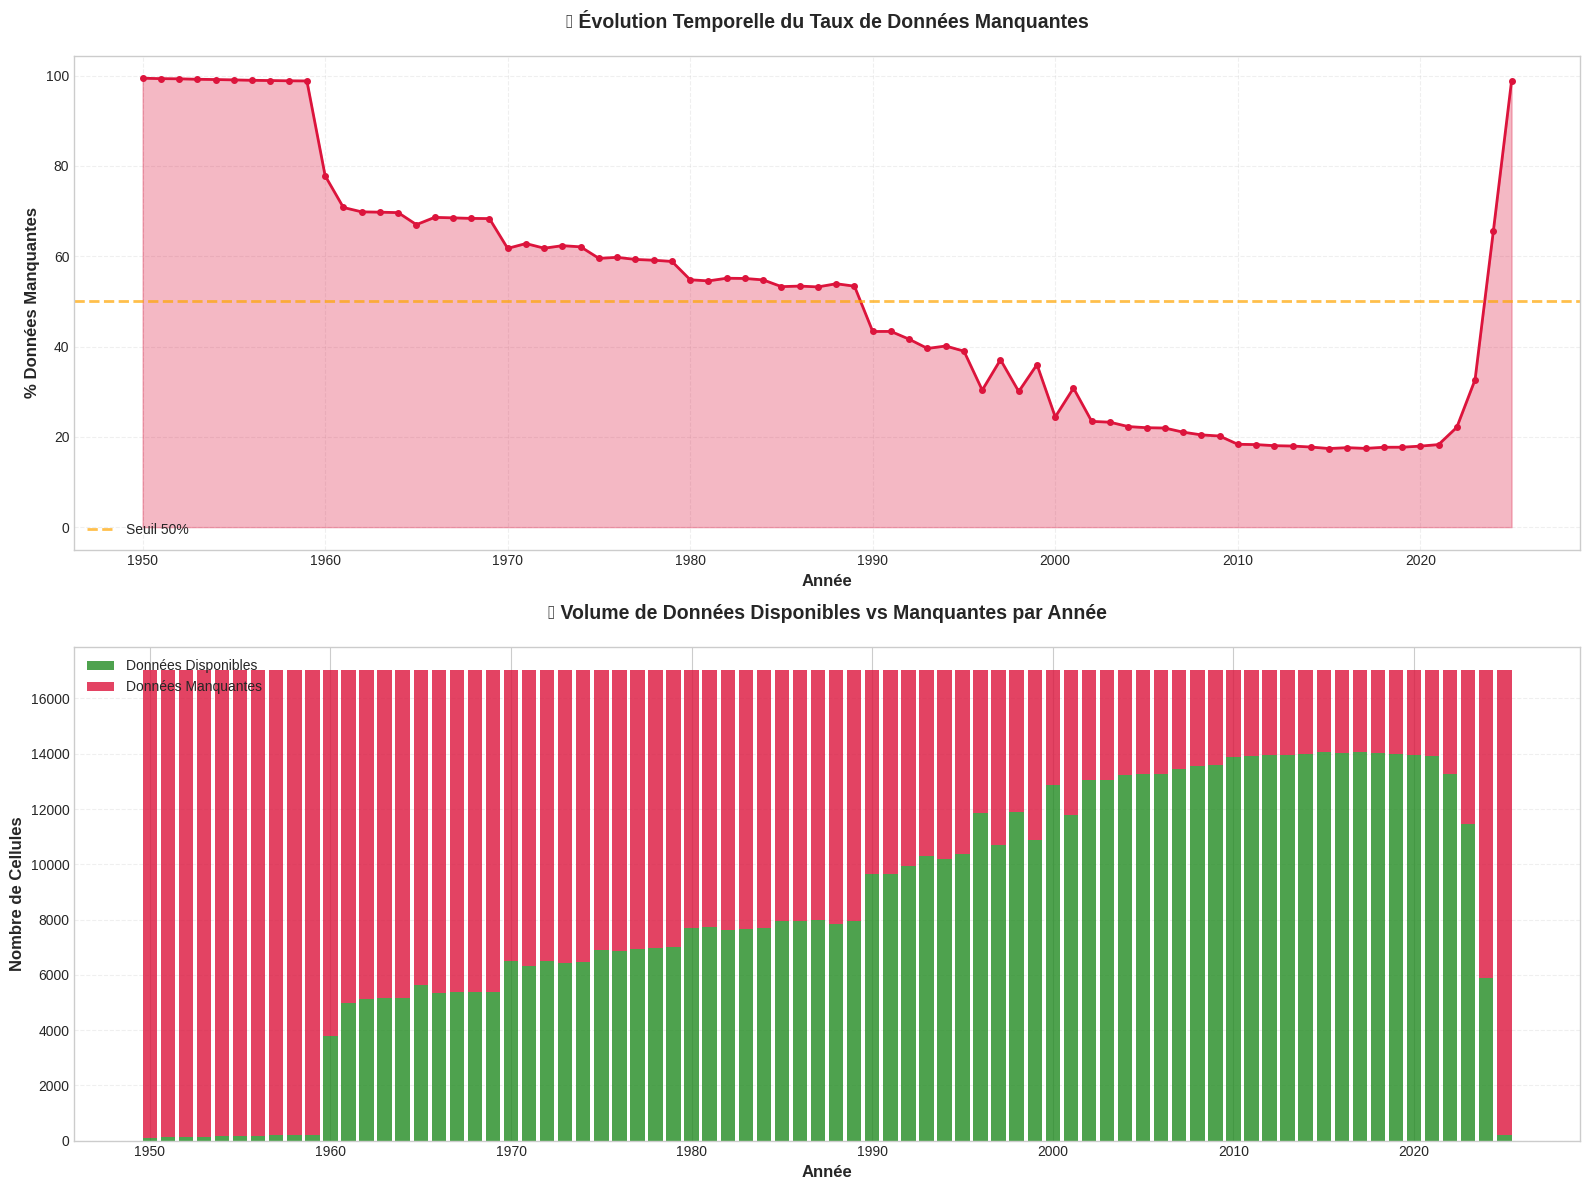

In [6]:
# Graphique: Évolution temporelle du taux de données manquantes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Graphique 1: Taux de données manquantes par année
ax1.plot(missing_by_year.index, missing_by_year['pct_missing'] * 100, 
         linewidth=2, marker='o', markersize=4, color='crimson')
ax1.fill_between(missing_by_year.index, missing_by_year['pct_missing'] * 100, 
                  alpha=0.3, color='crimson')
ax1.set_xlabel('Année', fontsize=12, fontweight='bold')
ax1.set_ylabel('% Données Manquantes', fontsize=12, fontweight='bold')
ax1.set_title('📉 Évolution Temporelle du Taux de Données Manquantes', 
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(alpha=0.3, linestyle='--')
ax1.axhline(y=50, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Seuil 50%')
ax1.legend(fontsize=10)

# Graphique 2: Nombre absolu de données disponibles vs manquantes
ax2.bar(missing_by_year.index, missing_by_year['total_cells'] - missing_by_year['n_missing'], 
        label='Données Disponibles', color='forestgreen', alpha=0.8)
ax2.bar(missing_by_year.index, missing_by_year['n_missing'], 
        bottom=missing_by_year['total_cells'] - missing_by_year['n_missing'],
        label='Données Manquantes', color='crimson', alpha=0.8)
ax2.set_xlabel('Année', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nombre de Cellules', fontsize=12, fontweight='bold')
ax2.set_title('📊 Volume de Données Disponibles vs Manquantes par Année', 
              fontsize=14, fontweight='bold', pad=20)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### 2.3 Heatmap de Complétude par Indicateur et Période

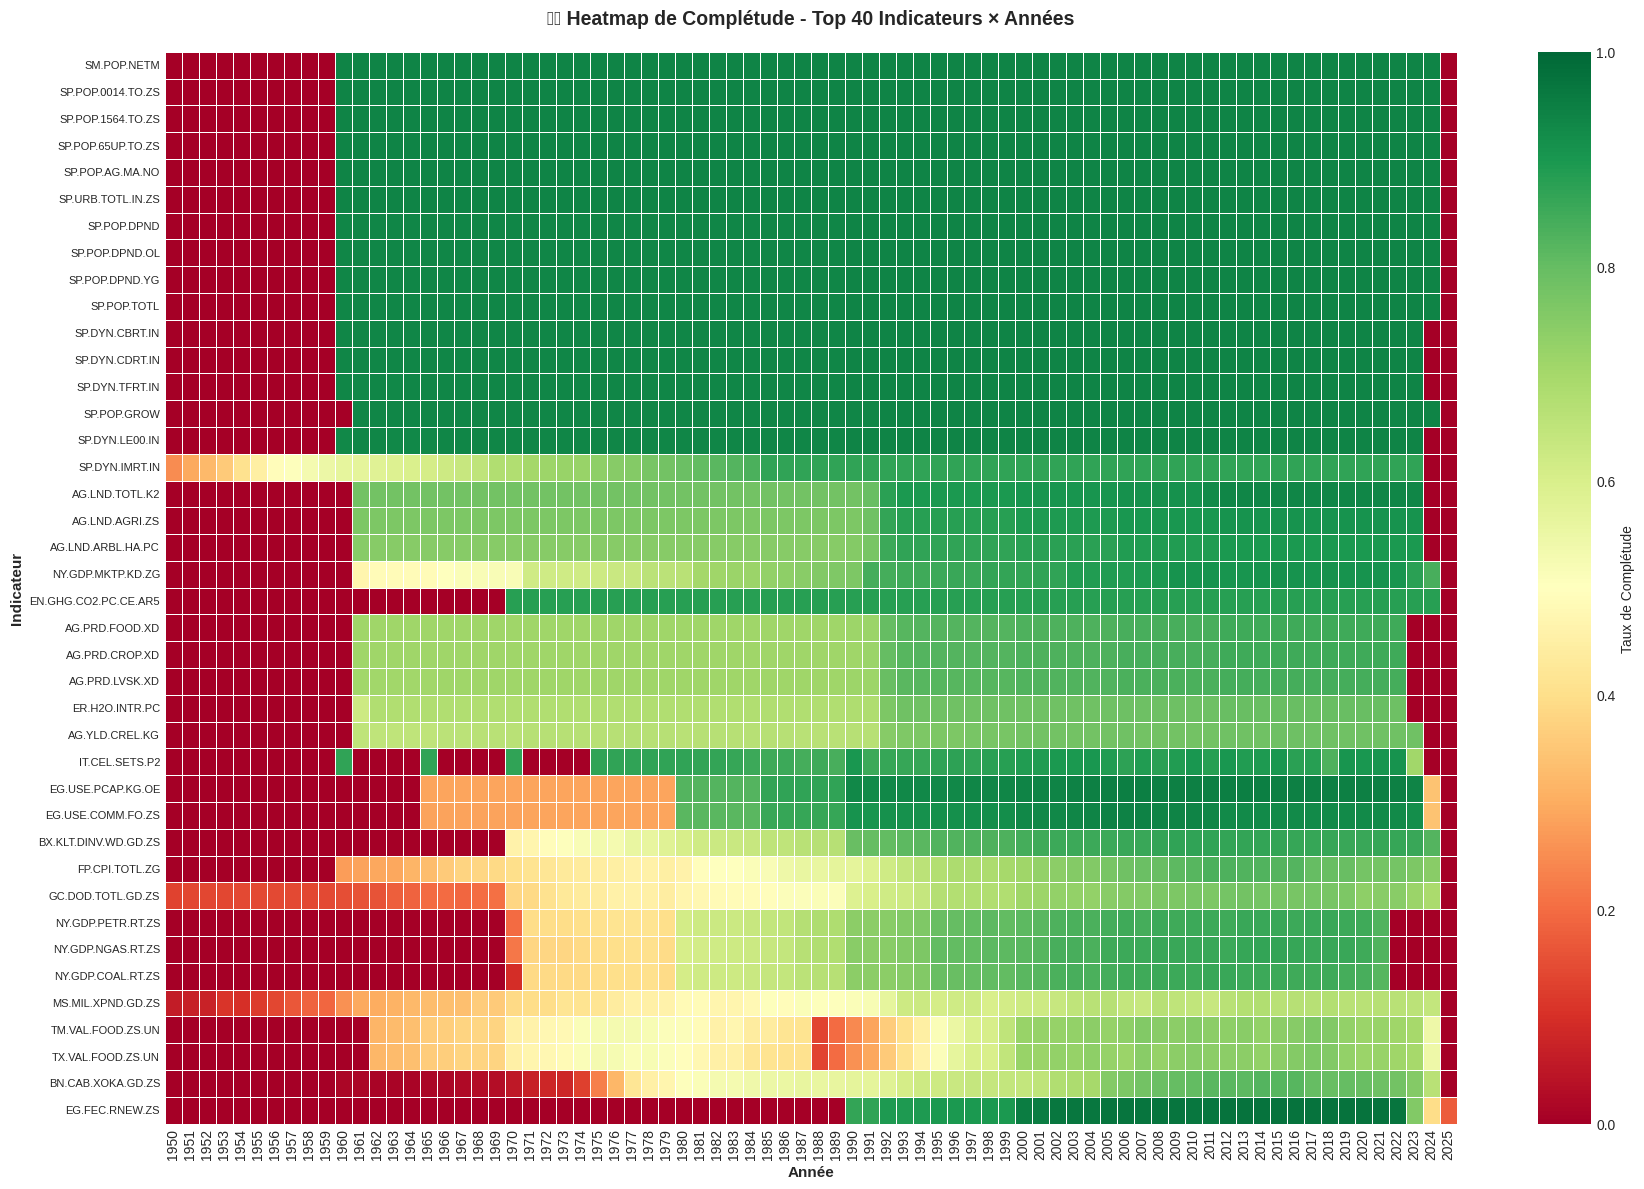


📌 Interprétation:
  🟢 Vert foncé = Haute complétude (données disponibles pour la majorité des pays)
  🟡 Jaune = Complétude moyenne (~50% des pays)
  🔴 Rouge = Faible complétude (peu de pays ont des données)


In [7]:
# Créer une matrice de complétude: Indicateur × Année
# (Taux de pays ayant des données pour chaque combinaison indicateur-année)
completeness_matrix = df_complete.groupby(['indicator_code', 'year'])['is_missing'].apply(
    lambda x: 1 - x.mean()  # Taux de complétude
).unstack(fill_value=0)

# Réduire si trop d'indicateurs (top 40 par complétude moyenne)
top_indicators = completeness_matrix.mean(axis=1).nlargest(40).index
completeness_subset = completeness_matrix.loc[top_indicators]

fig, ax = plt.subplots(figsize=(18, 12))

sns.heatmap(completeness_subset, cmap='RdYlGn', center=0.5, 
            vmin=0, vmax=1, cbar_kws={'label': 'Taux de Complétude'},
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_title('🗺️ Heatmap de Complétude - Top 40 Indicateurs × Années', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Année', fontsize=11, fontweight='bold')
ax.set_ylabel('Indicateur', fontsize=11, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.show()

print("\n📌 Interprétation:")
print("  🟢 Vert foncé = Haute complétude (données disponibles pour la majorité des pays)")
print("  🟡 Jaune = Complétude moyenne (~50% des pays)")
print("  🔴 Rouge = Faible complétude (peu de pays ont des données)")

## 3️⃣ Analyse des Patterns de Missingness

### 3.1 Classification des Indicateurs par Qualité de Données


📊 CLASSIFICATION DES INDICATEURS PAR QUALITÉ DE DONNÉES

  🔴 Faible (>60% manquant): 31 indicateurs (41.9%)
  🟠 Moyen (40-60% manquant): 19 indicateurs (25.7%)
  🟡 Bon (20-40% manquant): 14 indicateurs (18.9%)
  🟢 Excellent (<20% manquant): 10 indicateurs (13.5%)


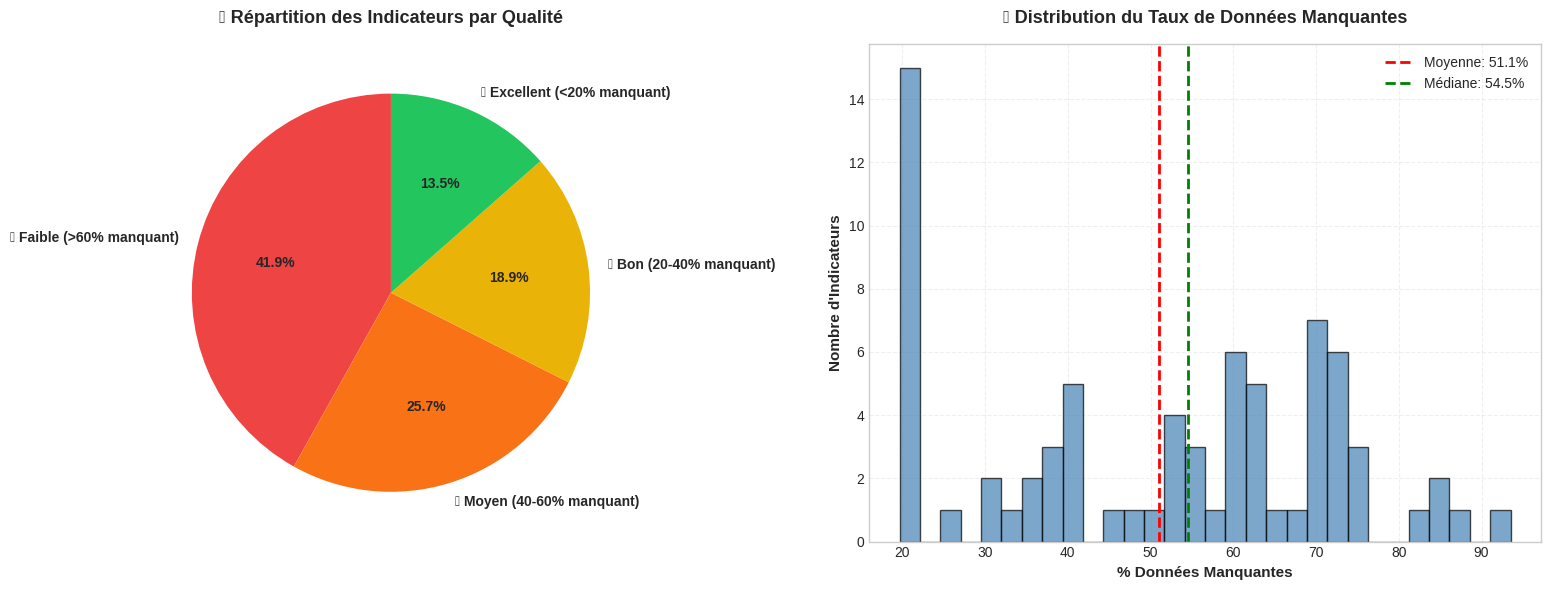

In [8]:
# Classifier les indicateurs selon leur complétude
def classify_completeness(pct_missing):
    if pct_missing < 0.2:
        return '🟢 Excellent (<20% manquant)'
    elif pct_missing < 0.4:
        return '🟡 Bon (20-40% manquant)'
    elif pct_missing < 0.6:
        return '🟠 Moyen (40-60% manquant)'
    else:
        return '🔴 Faible (>60% manquant)'

missing_by_indicator['quality'] = missing_by_indicator['pct_missing'].apply(classify_completeness)
quality_counts = missing_by_indicator['quality'].value_counts().sort_index()

print("\n📊 CLASSIFICATION DES INDICATEURS PAR QUALITÉ DE DONNÉES\n")
print("="*70)
for quality, count in quality_counts.items():
    pct = count / len(missing_by_indicator) * 100
    print(f"  {quality}: {count} indicateurs ({pct:.1f}%)")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = ['#ef4444', '#f97316', '#eab308', '#22c55e']
ax1.pie(quality_counts.values, labels=quality_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax1.set_title('📊 Répartition des Indicateurs par Qualité', 
             fontsize=13, fontweight='bold', pad=15)

# Distribution du taux de données manquantes
ax2.hist(missing_by_indicator['pct_missing'] * 100, bins=30, 
        edgecolor='black', color='steelblue', alpha=0.7)
ax2.axvline(missing_by_indicator['pct_missing'].mean() * 100, color='red', 
           linestyle='--', linewidth=2, label=f"Moyenne: {missing_by_indicator['pct_missing'].mean()*100:.1f}%")
ax2.axvline(missing_by_indicator['pct_missing'].median() * 100, color='green', 
           linestyle='--', linewidth=2, label=f"Médiane: {missing_by_indicator['pct_missing'].median()*100:.1f}%")
ax2.set_xlabel('% Données Manquantes', fontsize=11, fontweight='bold')
ax2.set_ylabel('Nombre d\'Indicateurs', fontsize=11, fontweight='bold')
ax2.set_title('📊 Distribution du Taux de Données Manquantes', 
             fontsize=13, fontweight='bold', pad=15)
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

### 3.2 Patterns Spatiaux (par Pays)


🌍 ANALYSE SPATIALE - COMPLÉTUDE PAR PAYS


🏆 Top 10 Pays - Meilleure complétude:
  1. TUR: 63.4% complétude (3565/5624 cellules)
  2. MEX: 63.3% complétude (3558/5624 cellules)
  3. ITA: 63.2% complétude (3552/5624 cellules)
  4. FRA: 62.9% complétude (3536/5624 cellules)
  5. PAK: 62.7% complétude (3529/5624 cellules)
  6. DNK: 62.7% complétude (3527/5624 cellules)
  7. ESP: 62.7% complétude (3525/5624 cellules)
  8. NOR: 62.5% complétude (3518/5624 cellules)
  9. THA: 62.5% complétude (3516/5624 cellules)
  10. GBR: 62.5% complétude (3513/5624 cellules)

📉 Flop 10 Pays - Faible complétude:
  1. ATA: 0.8% complétude (44/5624 cellules)
  2. ESH: 2.4% complétude (138/5624 cellules)
  3. MTQ: 2.6% complétude (148/5624 cellules)
  4. AIA: 2.9% complétude (166/5624 cellules)
  5. GLP: 3.3% complétude (185/5624 cellules)
  6. SPM: 3.6% complétude (203/5624 cellules)
  7. FLK: 3.6% complétude (203/5624 cellules)
  8. SHN: 3.6% complétude (203/5624 cellules)
  9. GUF: 3.8% complétude (214/56

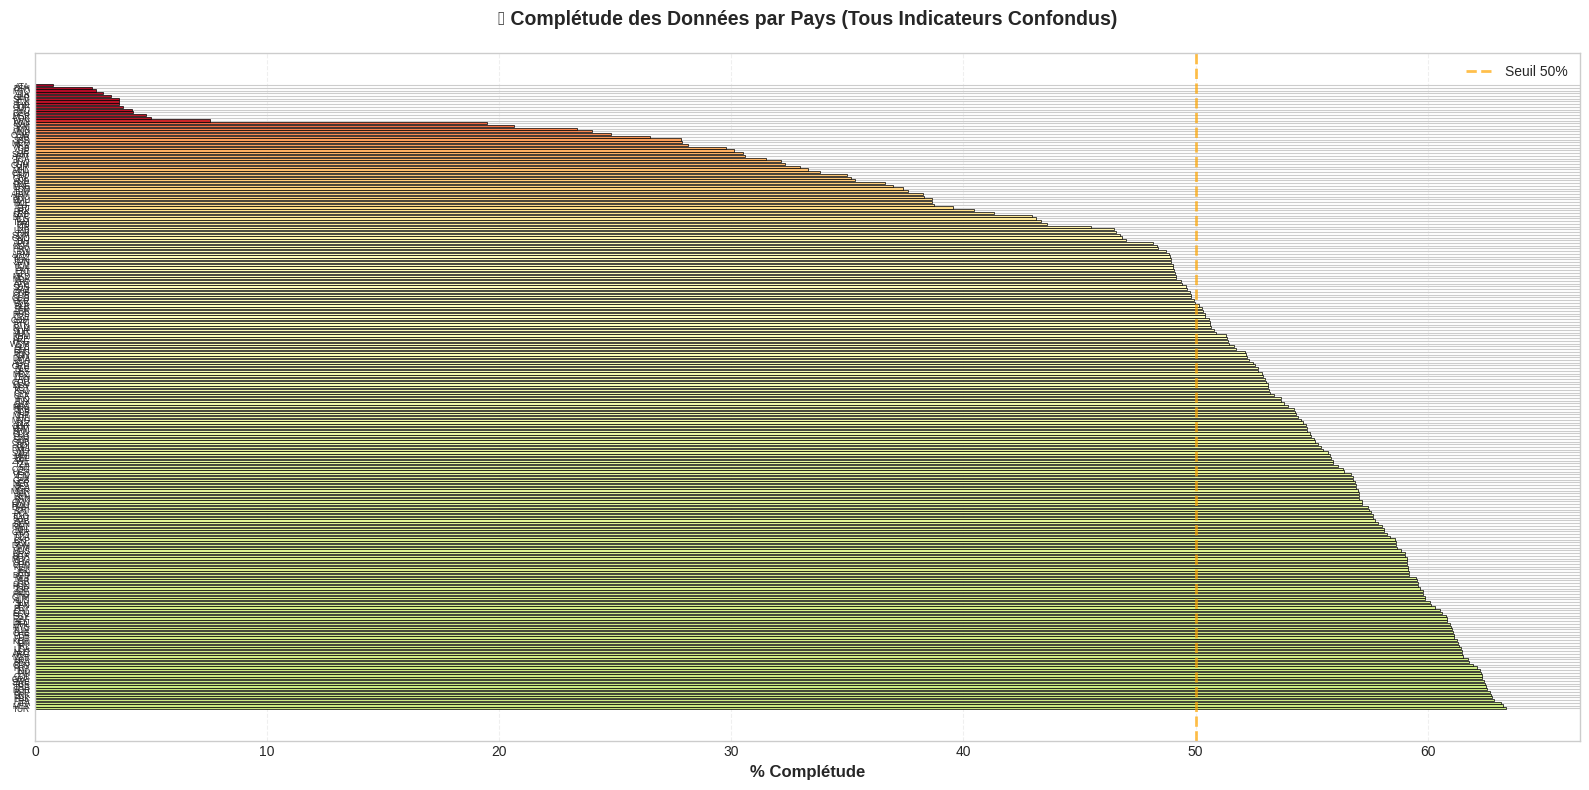

In [9]:
# Top et Flop pays
print("\n🌍 ANALYSE SPATIALE - COMPLÉTUDE PAR PAYS\n")
print("="*70)

print("\n🏆 Top 10 Pays - Meilleure complétude:")
best_countries = missing_by_country.nsmallest(10, 'pct_missing')
for idx, (country, row) in enumerate(best_countries.iterrows(), 1):
    print(f"  {idx}. {country}: {(1-row['pct_missing'])*100:.1f}% complétude ({row['total_cells'] - row['n_missing']:.0f}/{row['total_cells']:.0f} cellules)")

print("\n📉 Flop 10 Pays - Faible complétude:")
worst_countries = missing_by_country.nlargest(10, 'pct_missing')
for idx, (country, row) in enumerate(worst_countries.iterrows(), 1):
    print(f"  {idx}. {country}: {(1-row['pct_missing'])*100:.1f}% complétude ({row['total_cells'] - row['n_missing']:.0f}/{row['total_cells']:.0f} cellules)")

# Visualisation
fig, ax = plt.subplots(figsize=(16, 8))

sorted_countries = missing_by_country.sort_values('pct_missing')
colors_gradient = plt.cm.RdYlGn(1 - sorted_countries['pct_missing'].values)

ax.barh(range(len(sorted_countries)), (1 - sorted_countries['pct_missing']) * 100,
       color=colors_gradient, edgecolor='black', linewidth=0.5)

ax.set_yticks(range(len(sorted_countries)))
ax.set_yticklabels(sorted_countries.index, fontsize=6)
ax.set_xlabel('% Complétude', fontsize=12, fontweight='bold')
ax.set_title('🌍 Complétude des Données par Pays (Tous Indicateurs Confondus)', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.axvline(x=50, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Seuil 50%')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 4️⃣ Tests Statistiques du Mécanisme de Missingness

### Théorie des Mécanismes de Données Manquantes

- **MCAR (Missing Completely At Random)**: Les données manquantes sont totalement aléatoires, indépendantes de toutes variables (observées ou non)
- **MAR (Missing At Random)**: Les données manquantes dépendent des variables observées, mais pas des valeurs manquantes elles-mêmes
- **MNAR (Missing Not At Random)**: Les données manquantes dépendent des valeurs manquantes elles-mêmes

### 4.1 Test de Little's MCAR

In [10]:
# Test de Little pour MCAR (sur un échantillon d'indicateurs)
# Note: Ce test est computationally intensive, on le fait sur un sous-ensemble

print("\n🔬 TESTS STATISTIQUES DU MÉCANISME DE MISSINGNESS\n")
print("="*70)
print("\n⚠️ Note: Les tests sont effectués sur un échantillon représentatif")
print("   pour des raisons de performance computationnelle.\n")

# Sélectionner un échantillon stratifié d'indicateurs (par catégorie)
sample_indicators = df_raw.groupby('category_id')['indicator_code'].apply(
    lambda x: x.sample(min(3, len(x)), random_state=42)
).values

# Créer une matrice pivotée pour l'analyse
# Pays × (Indicateurs × Années) - on prend une fenêtre temporelle récente
recent_years = range(2010, 2023)
df_sample = df_complete[
    (df_complete['indicator_code'].isin(sample_indicators)) & 
    (df_complete['year'].isin(recent_years))
]

print(f"📊 Échantillon pour tests:")
print(f"  • {len(sample_indicators)} indicateurs")
print(f"  • {len(recent_years)} années ({min(recent_years)}-{max(recent_years)})")
print(f"  • {df_sample['country_code'].nunique()} pays")
print(f"  • Taux de données manquantes: {df_sample['is_missing'].mean()*100:.1f}%")


🔬 TESTS STATISTIQUES DU MÉCANISME DE MISSINGNESS


⚠️ Note: Les tests sont effectués sur un échantillon représentatif
   pour des raisons de performance computationnelle.

📊 Échantillon pour tests:
  • 24 indicateurs
  • 13 années (2010-2022)
  • 230 pays
  • Taux de données manquantes: 22.1%


### 4.2 Tests de Corrélation avec le Missingness

In [11]:
# Tester si le missingness est corrélé avec des variables observables

# 1. Corrélation temporelle: Le missingness dépend-il de l'année?
corr_time = df_complete.groupby('year')['is_missing'].mean()
corr_time_pearson, p_time = stats.pearsonr(corr_time.index, corr_time.values)

print("\n🔍 TEST 1: Corrélation Temporelle")
print(f"  Corrélation Pearson (année vs taux missing): r={corr_time_pearson:.3f}, p={p_time:.4f}")
if p_time < 0.01:
    print("  ✅ Significatif: Le missingness dépend significativement de l'année")
    print("  ➡️ Indicateur MAR (au minimum) - NOT MCAR")
else:
    print("  ❌ Non significatif: Pas d'évidence de dépendance temporelle")

# 2. Test de variation entre indicateurs
missing_var_indicators = missing_by_indicator['pct_missing'].var()
print(f"\n🔍 TEST 2: Variance entre Indicateurs")
print(f"  Variance du taux de missing entre indicateurs: {missing_var_indicators:.4f}")
if missing_var_indicators > 0.01:
    print("  ✅ Variance élevée: Le missingness varie fortement selon l'indicateur")
    print("  ➡️ Indicateur MAR - Les patterns dépendent du type d'indicateur")
else:
    print("  ❌ Variance faible: Missingness homogène entre indicateurs")

# 3. Test de variation entre pays
missing_var_countries = missing_by_country['pct_missing'].var()
print(f"\n🔍 TEST 3: Variance entre Pays")
print(f"  Variance du taux de missing entre pays: {missing_var_countries:.4f}")
if missing_var_countries > 0.01:
    print("  ✅ Variance élevée: Le missingness varie fortement selon le pays")
    print("  ➡️ Indicateur MAR - Les patterns dépendent du pays")
else:
    print("  ❌ Variance faible: Missingness homogène entre pays")

# 4. Test Chi² d'indépendance (Indicateur × Missingness)
contingency_indicator = pd.crosstab(
    df_sample['indicator_code'], 
    df_sample['is_missing']
)
chi2_ind, p_ind, dof_ind, expected_ind = stats.chi2_contingency(contingency_indicator)

print(f"\n🔍 TEST 4: Test Chi² - Indépendance Indicateur×Missingness")
print(f"  Chi²={chi2_ind:.2f}, p={p_ind:.4e}, df={dof_ind}")
if p_ind < 0.01:
    print("  ✅ Significatif: Le missingness dépend de l'indicateur")
    print("  ➡️ Rejet de MCAR")
else:
    print("  ❌ Non significatif: Pas d'évidence de dépendance à l'indicateur")


🔍 TEST 1: Corrélation Temporelle
  Corrélation Pearson (année vs taux missing): r=-0.851, p=0.0000
  ✅ Significatif: Le missingness dépend significativement de l'année
  ➡️ Indicateur MAR (au minimum) - NOT MCAR

🔍 TEST 2: Variance entre Indicateurs
  Variance du taux de missing entre indicateurs: 0.0451
  ✅ Variance élevée: Le missingness varie fortement selon l'indicateur
  ➡️ Indicateur MAR - Les patterns dépendent du type d'indicateur

🔍 TEST 3: Variance entre Pays
  Variance du taux de missing entre pays: 0.0223
  ✅ Variance élevée: Le missingness varie fortement selon le pays
  ➡️ Indicateur MAR - Les patterns dépendent du pays

🔍 TEST 4: Test Chi² - Indépendance Indicateur×Missingness
  Chi²=10246.54, p=0.0000e+00, df=19
  ✅ Significatif: Le missingness dépend de l'indicateur
  ➡️ Rejet de MCAR


### 4.3 Synthèse du Mécanisme de Missingness

In [12]:
print("\n" + "="*70)
print("📋 SYNTHÈSE: MÉCANISME DE DONNÉES MANQUANTES")
print("="*70)

# Scoring
mcar_score = 0
mar_score = 0
mnar_indicators = []

# Critères
if p_time < 0.01:
    mar_score += 1
    print("\n✅ Évidence MAR: Dépendance temporelle significative")
else:
    mcar_score += 1

if missing_var_indicators > 0.01:
    mar_score += 1
    print("✅ Évidence MAR: Variation élevée entre indicateurs")
else:
    mcar_score += 1

if missing_var_countries > 0.01:
    mar_score += 1
    print("✅ Évidence MAR: Variation élevée entre pays")
else:
    mcar_score += 1

if p_ind < 0.01:
    mar_score += 1
    print("✅ Évidence MAR: Test Chi² significatif (indicateur×missingness)")
else:
    mcar_score += 1

# Détection MNAR: Indicateurs avec >80% de données manquantes (suspect)
suspect_mnar = missing_by_indicator[missing_by_indicator['pct_missing'] > 0.8]
if len(suspect_mnar) > 0:
    print(f"\n⚠️ Évidence potentielle MNAR: {len(suspect_mnar)} indicateurs avec >80% de données manquantes")
    print("   Ces indicateurs pourraient souffrir de biais de collecte structurels")
    mnar_indicators = suspect_mnar.index.tolist()[:5]
    print(f"   Exemples: {', '.join(mnar_indicators)}")

print("\n" + "="*70)
print("🎯 CONCLUSION:")
print("="*70)

if mar_score >= 3:
    print("\n📊 Mécanisme dominant: **MAR (Missing At Random)**")
    print("\nJustification:")
    print("  • Les données manquantes dépendent de variables observées")
    print("    (pays, indicateur, année)")
    print("  • Le missingness n'est PAS complètement aléatoire (MCAR rejeté)")
    print("  • Patterns structurels identifiés: temporels, géographiques, thématiques")
    print("\nImplications pour l'imputation:")
    print("  ✅ L'imputation est légitime et peut être efficace")
    print("  ✅ Utiliser des modèles conditionnels (par pays, par indicateur)")
    print("  ✅ Les méthodes de séries temporelles sont appropriées")
    
elif mcar_score >= 3:
    print("\n📊 Mécanisme dominant: **MCAR (Missing Completely At Random)**")
    print("\nJustification:")
    print("  • Pas d'évidence de patterns systématiques")
    print("  • Le missingness semble aléatoire")
    print("\nImplications pour l'imputation:")
    print("  ✅ Toute méthode d'imputation est valide")
    print("  ✅ Pas de biais introduit par la suppression de données manquantes")
else:
    print("\n📊 Mécanisme: **Mixte (MAR + possiblement MNAR)**")
    print("\nJustification:")
    print("  • Présence de patterns MAR")
    print("  • Certains indicateurs montrent des patterns suspects (MNAR potentiel)")
    print("\nImplications pour l'imputation:")
    print("  ⚠️ Prudence requise")
    print("  ✅ Imputation conditionnelle recommandée")
    print("  ⚠️ Analyse de sensibilité nécessaire pour indicateurs suspects")

if len(mnar_indicators) > 0:
    print(f"\n⚠️ ALERTE MNAR: Les indicateurs suivants nécessitent une attention particulière:")
    for ind in mnar_indicators:
        print(f"   • {ind}")


📋 SYNTHÈSE: MÉCANISME DE DONNÉES MANQUANTES

✅ Évidence MAR: Dépendance temporelle significative
✅ Évidence MAR: Variation élevée entre indicateurs
✅ Évidence MAR: Variation élevée entre pays
✅ Évidence MAR: Test Chi² significatif (indicateur×missingness)

⚠️ Évidence potentielle MNAR: 5 indicateurs avec >80% de données manquantes
   Ces indicateurs pourraient souffrir de biais de collecte structurels
   Exemples: SE.ADT.LITR.ZS, SP.POP.SCIE.RD.P6, TX.VAL.TECH.MF.ZS, GB.XPD.RSDV.GD.ZS, IT.NET.SECR.P6

🎯 CONCLUSION:

📊 Mécanisme dominant: **MAR (Missing At Random)**

Justification:
  • Les données manquantes dépendent de variables observées
    (pays, indicateur, année)
  • Le missingness n'est PAS complètement aléatoire (MCAR rejeté)
  • Patterns structurels identifiés: temporels, géographiques, thématiques

Implications pour l'imputation:
  ✅ L'imputation est légitime et peut être efficace
  ✅ Utiliser des modèles conditionnels (par pays, par indicateur)
  ✅ Les méthodes de séries te

## 5️⃣ Stratégie d'Imputation pour Séries Temporelles Économiques

### 5.1 Cadre Méthodologique

In [13]:
print("\n" + "="*70)
print("🛠️ STRATÉGIE D'IMPUTATION RECOMMANDÉE")
print("="*70)

print("""
### PRINCIPES DIRECTEURS

1. **Hiérarchie des Méthodes** (du moins au plus sophistiqué):
   
   a) **Interpolation Linéaire Simple**
      - Pour: Séries continues avec peu de gaps (<3 années)
      - Quand: Indicateurs économiques stables (PIB, population)
      - Limite: Suppose tendance linéaire
   
   b) **Interpolation Spline Cubique**
      - Pour: Séries avec tendances non-linéaires
      - Quand: Gaps moyens (3-5 années), données lisses
      - Limite: Peut créer des oscillations artificielles
   
   c) **LOCF/NOCB (Last/Next Observation Carried Forward/Backward)**
      - Pour: Variables discrètes ou structurelles (régime politique)
      - Quand: Stabilité supposée entre observations
      - Limite: Sous-estime la variabilité
   
   d) **Modèles ARIMA/SARIMA**
      - Pour: Séries avec saisonnalité ou autocorrélation forte
      - Quand: Suffisamment de données pour estimation (>30 obs)
      - Limite: Computationally intensive
   
   e) **Imputation Multivariée (MICE, MissForest)**
      - Pour: Exploiter corrélations entre indicateurs
      - Quand: Patterns MAR confirmés, indicateurs corrélés
      - Limite: Complexité, assumptions de normalité

2. **Règles de Décision**:
   
   • Gap <20% d'une série → Interpolation linéaire/spline
   • Gap 20-50% → Modèle conditionnel (pays voisins, indicateurs corrélés)
   • Gap >50% → NE PAS IMPUTER (trop incertain) ou modèle global
   • Début/fin de série → Utiliser données de pays similaires

3. **Validation**:
   
   • Validation croisée: Masquer données réelles, imputer, comparer
   • Analyse de sensibilité: Tester plusieurs méthodes
   • Marquage explicite: Toujours distinguer réel vs imputé
   • Intervalles de confiance: Si possible, fournir incertitude

4. **Précautions Spécifiques - Séries Économiques**:
   
   • Respecter les bornes naturelles (ex: taux 0-100%)
   • Éviter interpolation lors de chocs économiques connus
   • Considérer l'échelle (log-transformation pour variables exponentielles)
   • Vérifier cohérence inter-indicateurs (ex: PIB vs Population)
""")

print("\n" + "="*70)


🛠️ STRATÉGIE D'IMPUTATION RECOMMANDÉE

### PRINCIPES DIRECTEURS

1. **Hiérarchie des Méthodes** (du moins au plus sophistiqué):
   
   a) **Interpolation Linéaire Simple**
      - Pour: Séries continues avec peu de gaps (<3 années)
      - Quand: Indicateurs économiques stables (PIB, population)
      - Limite: Suppose tendance linéaire
   
   b) **Interpolation Spline Cubique**
      - Pour: Séries avec tendances non-linéaires
      - Quand: Gaps moyens (3-5 années), données lisses
      - Limite: Peut créer des oscillations artificielles
   
   c) **LOCF/NOCB (Last/Next Observation Carried Forward/Backward)**
      - Pour: Variables discrètes ou structurelles (régime politique)
      - Quand: Stabilité supposée entre observations
      - Limite: Sous-estime la variabilité
   
   d) **Modèles ARIMA/SARIMA**
      - Pour: Séries avec saisonnalité ou autocorrélation forte
      - Quand: Suffisamment de données pour estimation (>30 obs)
      - Limite: Computationally intensive
   
   e

### 5.2 Exemple d'Imputation - Approche Prudente

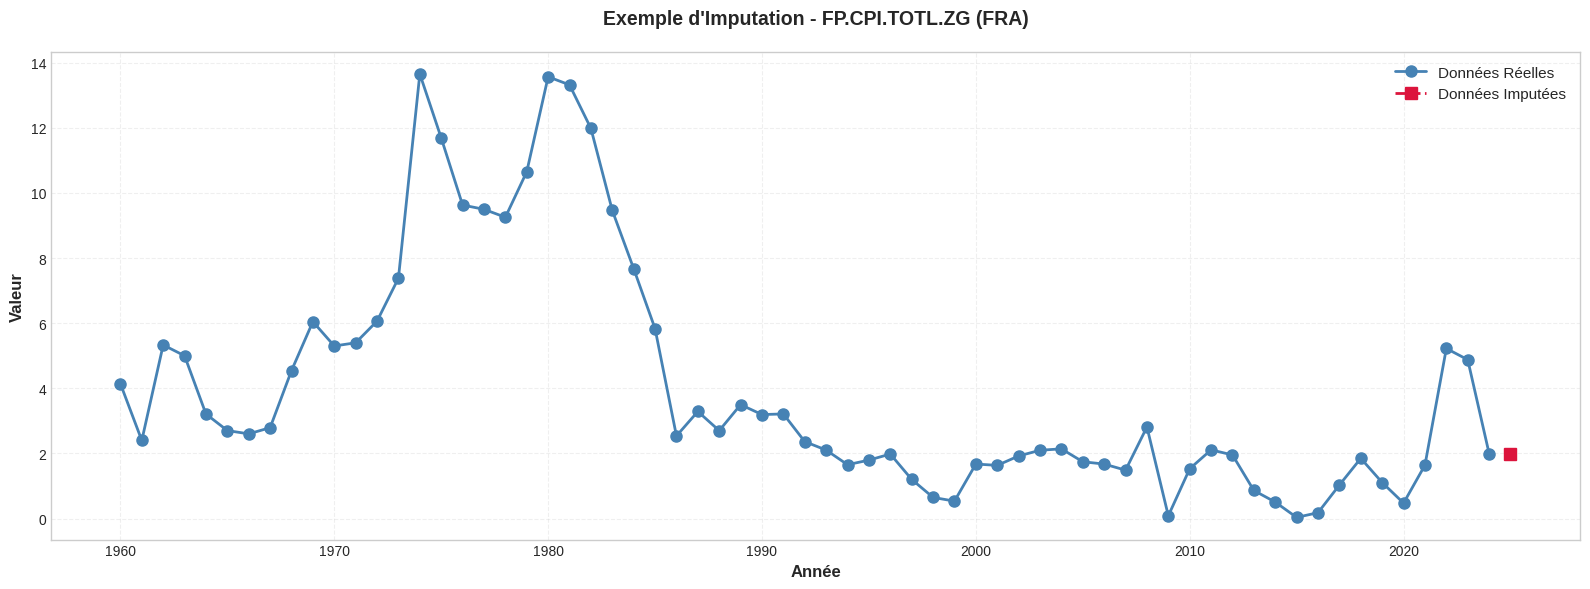


📊 Résumé de l'imputation:
  • Indicateur: FP.CPI.TOTL.ZG
  • Pays: FRA
  • Valeurs réelles: 75
  • Valeurs imputées: 1
  • Méthode: Interpolation linéaire (max gap: 3 ans)


In [14]:
# Fonction d'imputation avec traçabilité
def impute_time_series(series, method='linear', max_gap=5):
    """
    Impute une série temporelle avec marquage des valeurs imputées.
    
    Parameters:
    -----------
    series : pd.Series
        Série à imputer (index = années)
    method : str
        'linear', 'spline', 'locf', 'nocb'
    max_gap : int
        Taille maximale de gap à imputer
    
    Returns:
    --------
    pd.DataFrame avec colonnes: value, is_imputed, imputation_method
    """
    result = pd.DataFrame({
        'value': series.copy(),
        'is_imputed': False,
        'imputation_method': None
    })
    
    # Identifier les gaps
    missing_mask = series.isna()
    
    if not missing_mask.any():
        return result
    
    # Calculer tailles de gaps
    gap_sizes = missing_mask.astype(int).groupby(
        (missing_mask != missing_mask.shift()).cumsum()
    ).transform('sum')
    
    # Ne traiter que les gaps <= max_gap
    imputable_mask = missing_mask & (gap_sizes <= max_gap)
    
    if not imputable_mask.any():
        return result
    
    # Imputation selon méthode
    if method == 'linear':
        imputed_series = series.interpolate(method='linear')
        result.loc[imputable_mask, 'value'] = imputed_series[imputable_mask]
    elif method == 'spline':
        if len(series.dropna()) >= 4:  # Minimum pour spline cubique
            imputed_series = series.interpolate(method='spline', order=3, limit_area='inside')
            result.loc[imputable_mask, 'value'] = imputed_series[imputable_mask]
    elif method == 'locf':
        imputed_series = series.ffill()
        result.loc[imputable_mask, 'value'] = imputed_series[imputable_mask]
    elif method == 'nocb':
        imputed_series = series.bfill()
        result.loc[imputable_mask, 'value'] = imputed_series[imputable_mask]
    
    result.loc[imputable_mask, 'is_imputed'] = True
    result.loc[imputable_mask, 'imputation_method'] = method
    
    return result

# Démonstration sur un indicateur et un pays
demo_indicator = missing_by_indicator[missing_by_indicator['pct_missing'].between(0.2, 0.5)].index[0]
demo_country = 'FRA'  # France comme exemple

# Extraire série
demo_series = df_complete[
    (df_complete['indicator_code'] == demo_indicator) & 
    (df_complete['country_code'] == demo_country)
].set_index('year')['value'].sort_index()

# Appliquer imputation
demo_imputed = impute_time_series(demo_series, method='linear', max_gap=3)

# Visualisation
fig, ax = plt.subplots(figsize=(16, 6))

# Données réelles
real_data = demo_imputed[~demo_imputed['is_imputed']]
ax.plot(real_data.index, real_data['value'], 
       marker='o', linestyle='-', linewidth=2, markersize=8,
       color='steelblue', label='Données Réelles', zorder=3)

# Données imputées
imputed_data = demo_imputed[demo_imputed['is_imputed']]
if len(imputed_data) > 0:
    ax.plot(imputed_data.index, imputed_data['value'], 
           marker='s', linestyle='--', linewidth=2, markersize=8,
           color='crimson', label='Données Imputées', zorder=2)

ax.set_xlabel('Année', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur', fontsize=12, fontweight='bold')
ax.set_title(f'Exemple d\'Imputation - {demo_indicator} ({demo_country})', 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\n📊 Résumé de l'imputation:")
print(f"  • Indicateur: {demo_indicator}")
print(f"  • Pays: {demo_country}")
print(f"  • Valeurs réelles: {(~demo_imputed['is_imputed']).sum()}")
print(f"  • Valeurs imputées: {demo_imputed['is_imputed'].sum()}")
print(f"  • Méthode: Interpolation linéaire (max gap: 3 ans)")

## 6️⃣ Recommandations Finales

### Workflow Recommandé

In [15]:
print("""
╔═══════════════════════════════════════════════════════════════════╗
║                                                                   ║
║         📋 WORKFLOW D'ANALYSE ET IMPUTATION - RÉSUMÉ              ║
║                                                                   ║
╚═══════════════════════════════════════════════════════════════════╝

🔹 PHASE 1: DIAGNOSTIC (FAIT DANS CE NOTEBOOK)
   ✅ Cartographie du missingness
   ✅ Identification des patterns
   ✅ Classification des mécanismes (MCAR/MAR/MNAR)
   ✅ Évaluation de la qualité par dimension

🔹 PHASE 2: STRATIFICATION
   Pour chaque indicateur, classifier:
   • CLASSE A (missing <20%): Imputation légère (linéaire/spline)
   • CLASSE B (missing 20-50%): Imputation conditionnelle prudente
   • CLASSE C (missing 50-80%): Modèles globaux ou abandon
   • CLASSE D (missing >80%): NE PAS IMPUTER - Signaler comme incomplet

🔹 PHASE 3: IMPUTATION CONDITIONNELLE
   Pour chaque série (Pays × Indicateur):
   
   1. Calculer taille du gap le plus long
   2. Si gap ≤3 ans → Interpolation linéaire
   3. Si 3 < gap ≤5 ans → Interpolation spline ou modèle conditionnel
   4. Si gap >5 ans → Utiliser données pays voisins ou indicateurs corrélés
   5. Toujours marquer: is_imputed=True, method='xxx'

🔹 PHASE 4: VALIDATION
   1. Validation croisée temporelle (masquer 10% données, imputer, comparer)
   2. Vérifier cohérence inter-indicateurs
   3. Analyse de sensibilité (plusieurs méthodes)
   4. Documenter incertitude (intervalles de confiance si possible)

🔹 PHASE 5: PRODUCTION
   Créer dataset final avec:
   • value: Valeur (réelle ou imputée)
   • is_imputed: Boolean
   • imputation_method: 'none' | 'linear' | 'spline' | 'model' | ...
   • confidence: 'high' | 'medium' | 'low' (optionnel)

╔═══════════════════════════════════════════════════════════════════╗
║  ⚠️ RÈGLE D'OR: EN CAS DE DOUTE, NE PAS IMPUTER                  ║
║     Mieux vaut un dataset incomplet mais fiable qu'un dataset    ║
║     complet mais pollué par des imputations douteuses.          ║
╚═══════════════════════════════════════════════════════════════════╝

📚 RÉFÉRENCES MÉTHODOLOGIQUES:
   • Little & Rubin (2002): Statistical Analysis with Missing Data
   • Van Buuren (2018): Flexible Imputation of Missing Data (MICE)
   • Moritz & Bartz-Beielstein (2017): imputeTS package (R)
""")


╔═══════════════════════════════════════════════════════════════════╗
║                                                                   ║
║         📋 WORKFLOW D'ANALYSE ET IMPUTATION - RÉSUMÉ              ║
║                                                                   ║
╚═══════════════════════════════════════════════════════════════════╝

🔹 PHASE 1: DIAGNOSTIC (FAIT DANS CE NOTEBOOK)
   ✅ Cartographie du missingness
   ✅ Identification des patterns
   ✅ Classification des mécanismes (MCAR/MAR/MNAR)
   ✅ Évaluation de la qualité par dimension

🔹 PHASE 2: STRATIFICATION
   Pour chaque indicateur, classifier:
   • CLASSE A (missing <20%): Imputation légère (linéaire/spline)
   • CLASSE B (missing 20-50%): Imputation conditionnelle prudente
   • CLASSE C (missing 50-80%): Modèles globaux ou abandon
   • CLASSE D (missing >80%): NE PAS IMPUTER - Signaler comme incomplet

🔹 PHASE 3: IMPUTATION CONDITIONNELLE
   Pour chaque série (Pays × Indicateur):
   
   1. Calculer taille du gap

In [16]:
# Fermer connexion
conn.close()
print("\n✅ Connexion fermée")
print("\n🎯 Analyse des données manquantes terminée.")
print("   Les recommandations sont prêtes à être implémentées.")


✅ Connexion fermée

🎯 Analyse des données manquantes terminée.
   Les recommandations sont prêtes à être implémentées.
